# Data Types & Data Profiling

Understanding data types is fundamental — they determine which statistical methods and visualisations are valid.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Data Type Taxonomy

| Type | Examples | Valid operations |
|---|---|---|
| Continuous | age, fare | mean, std, correlation |
| Discrete | count of siblings | mean, mode, histogram |
| Nominal | gender, city | mode, frequency counts |
| Ordinal | class (1st/2nd/3rd) | median, rank correlation |

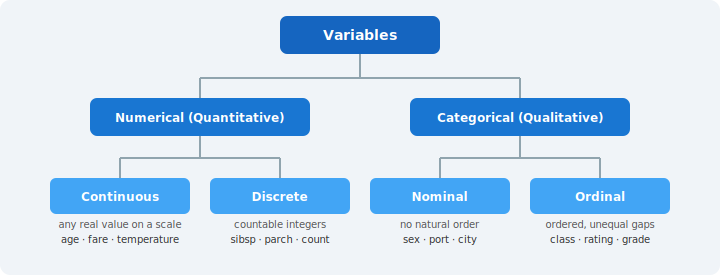

In [2]:
from IPython.display import SVG, display

_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="275"
     font-family="'Segoe UI', Arial, sans-serif">

  <!-- background -->
  <rect width="720" height="275" fill="#f0f4f8" rx="10"/>

  <!-- ── Root ── -->
  <rect x="280" y="16" width="160" height="38" rx="7" fill="#1565C0"/>
  <text x="360" y="40" text-anchor="middle" fill="white"
        font-size="14" font-weight="bold">Variables</text>

  <!-- root → horizontal branch -->
  <line x1="360" y1="54" x2="360" y2="78" stroke="#90A4AE" stroke-width="2"/>
  <line x1="200" y1="78" x2="520" y2="78" stroke="#90A4AE" stroke-width="2"/>
  <line x1="200" y1="78" x2="200" y2="98" stroke="#90A4AE" stroke-width="2"/>
  <line x1="520" y1="78" x2="520" y2="98" stroke="#90A4AE" stroke-width="2"/>

  <!-- ── Level 1 ── -->
  <rect x="90"  y="98" width="220" height="38" rx="7" fill="#1976D2"/>
  <text x="200" y="122" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Numerical (Quantitative)</text>

  <rect x="410" y="98" width="220" height="38" rx="7" fill="#1976D2"/>
  <text x="520" y="122" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Categorical (Qualitative)</text>

  <!-- Numerical → sub-branches -->
  <line x1="200" y1="136" x2="200" y2="158" stroke="#90A4AE" stroke-width="2"/>
  <line x1="120" y1="158" x2="280" y2="158" stroke="#90A4AE" stroke-width="2"/>
  <line x1="120" y1="158" x2="120" y2="178" stroke="#90A4AE" stroke-width="2"/>
  <line x1="280" y1="158" x2="280" y2="178" stroke="#90A4AE" stroke-width="2"/>

  <!-- Categorical → sub-branches -->
  <line x1="520" y1="136" x2="520" y2="158" stroke="#90A4AE" stroke-width="2"/>
  <line x1="440" y1="158" x2="600" y2="158" stroke="#90A4AE" stroke-width="2"/>
  <line x1="440" y1="158" x2="440" y2="178" stroke="#90A4AE" stroke-width="2"/>
  <line x1="600" y1="158" x2="600" y2="178" stroke="#90A4AE" stroke-width="2"/>

  <!-- ── Leaves ── -->
  <rect x="50"  y="178" width="140" height="36" rx="6" fill="#42A5F5"/>
  <text x="120" y="201" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Continuous</text>

  <rect x="210" y="178" width="140" height="36" rx="6" fill="#42A5F5"/>
  <text x="280" y="201" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Discrete</text>

  <rect x="370" y="178" width="140" height="36" rx="6" fill="#42A5F5"/>
  <text x="440" y="201" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Nominal</text>

  <rect x="530" y="178" width="140" height="36" rx="6" fill="#42A5F5"/>
  <text x="600" y="201" text-anchor="middle" fill="white"
        font-size="12" font-weight="bold">Ordinal</text>

  <!-- ── Examples ── -->
  <text x="120" y="228" text-anchor="middle" fill="#555" font-size="10"
        font-style="italic">any real value on a scale</text>
  <text x="120" y="243" text-anchor="middle" fill="#333" font-size="10">
        age · fare · temperature</text>

  <text x="280" y="228" text-anchor="middle" fill="#555" font-size="10"
        font-style="italic">countable integers</text>
  <text x="280" y="243" text-anchor="middle" fill="#333" font-size="10">
        sibsp · parch · count</text>

  <text x="440" y="228" text-anchor="middle" fill="#555" font-size="10"
        font-style="italic">no natural order</text>
  <text x="440" y="243" text-anchor="middle" fill="#333" font-size="10">
        sex · port · city</text>

  <text x="600" y="228" text-anchor="middle" fill="#555" font-size="10"
        font-style="italic">ordered, unequal gaps</text>
  <text x="600" y="243" text-anchor="middle" fill="#333" font-size="10">
        class · rating · grade</text>
</svg>"""

display(SVG(_svg))

In [3]:
# Raw pandas dtypes
print("Column dtypes:")
print(df.dtypes)
print()
print("Note: pandas 'object' dtype typically means string/categorical")

Column dtypes:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Note: pandas 'object' dtype typically means string/categorical


In [4]:
# Programmatically separate numerical and categorical
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical columns:", num_vars)
print("Categorical columns:", cat_vars)

Numerical columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [5]:
# Check cardinality (unique values) — helps distinguish discrete from continuous
print("Unique value counts per column:")
unique_counts = df.nunique().sort_values()
print(unique_counts)
print()
print("Low cardinality numerics (e.g., pclass, survived) are often ordinal or binary")

Unique value counts per column:
survived         2
sex              2
alive            2
adult_male       2
alone            2
class            3
pclass           3
embarked         3
embark_town      3
who              3
sibsp            7
parch            7
deck             7
age             88
fare           248
dtype: int64

Low cardinality numerics (e.g., pclass, survived) are often ordinal or binary


## Impact of Data Types on Analysis

| Data Type | Statistical Methods | Encoding for ML |
|---|---|---|
| Numerical | mean, std, correlation, regression | use as-is (after scaling) |
| Categorical (nominal) | frequency, mode | one-hot encoding |
| Categorical (ordinal) | median, rank | label encoding |
| Time-series | trend, seasonality | extract year/month/lag features |
| Text | word frequency | tokenisation, TF-IDF, embeddings |

## Choosing the Right Chart

| Data Type | Best Charts |
|---|---|
| Numerical (distribution) | Histogram, KDE plot, boxplot |
| Numerical (relationship) | Scatter plot, line plot |
| Categorical | Bar chart, pie chart, count plot |
| Numerical vs Categorical | Box plot, violin plot, strip plot |
| Two Categorical | Stacked bar, heatmap (crosstab) |
| **Time-series** | **Line chart, decomposition plot, lag plot** |
| **Text** | **Word cloud, bar chart of top terms, topic frequency plot** |

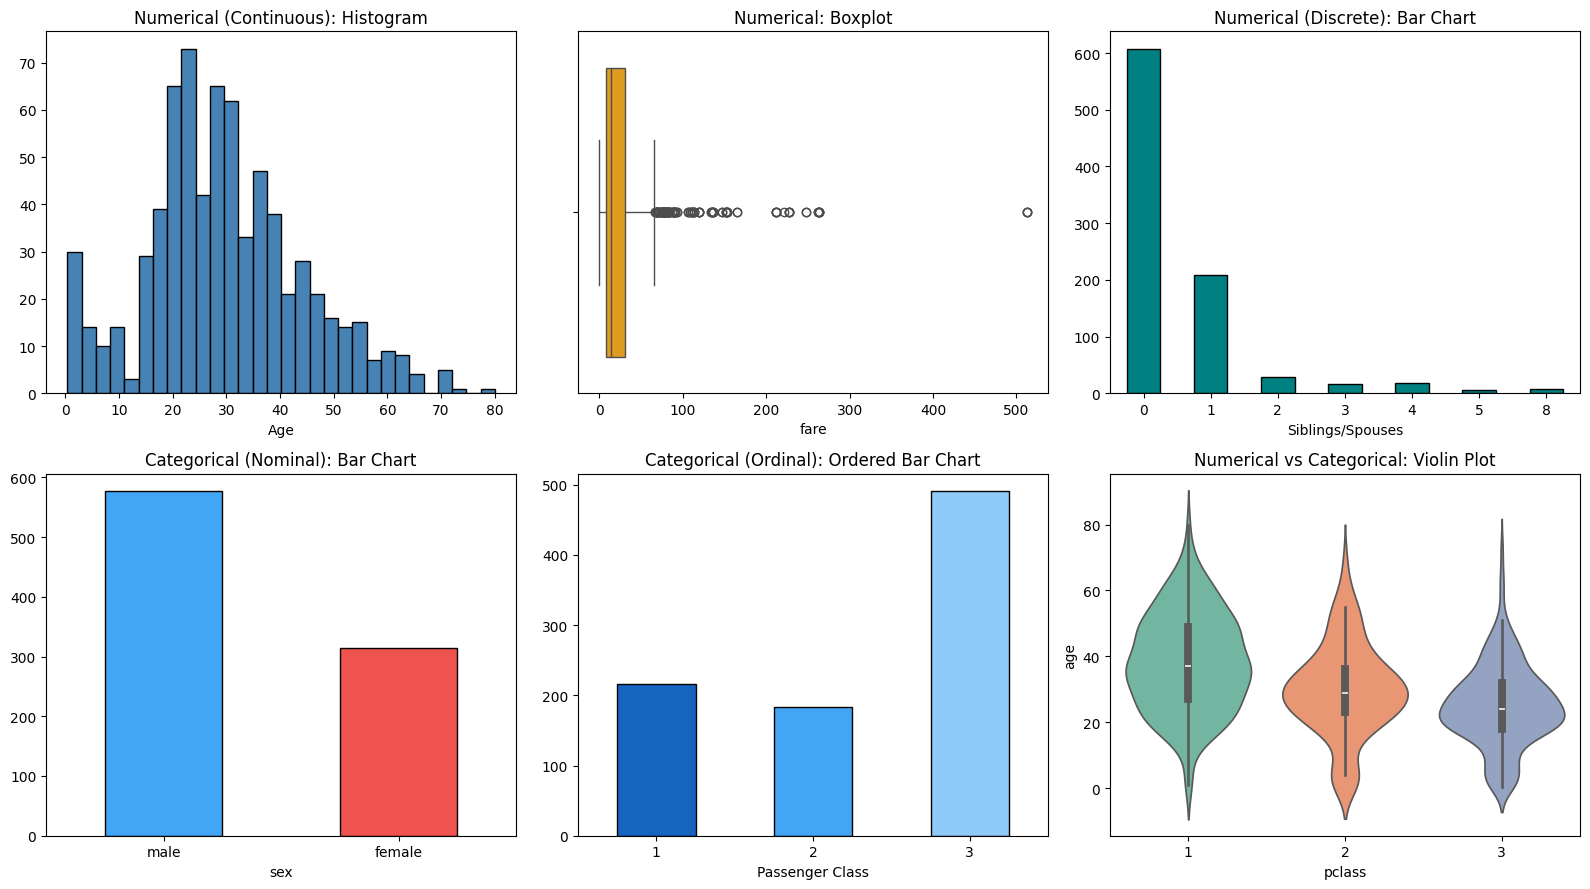

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Numerical — distribution
axes[0][0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0][0].set_title('Numerical (Continuous): Histogram')
axes[0][0].set_xlabel('Age')

# Numerical — boxplot
sns.boxplot(x=df['fare'], ax=axes[0][1], color='orange')
axes[0][1].set_title('Numerical: Boxplot')

# Discrete — bar chart
df['sibsp'].value_counts().sort_index().plot(kind='bar', ax=axes[0][2],
                                              color='teal', edgecolor='black')
axes[0][2].set_title('Numerical (Discrete): Bar Chart')
axes[0][2].set_xlabel('Siblings/Spouses')
axes[0][2].tick_params(rotation=0)

# Categorical nominal — count plot
df['sex'].value_counts().plot(kind='bar', ax=axes[1][0],
                               color=['#42A5F5', '#EF5350'], edgecolor='black')
axes[1][0].set_title('Categorical (Nominal): Bar Chart')
axes[1][0].tick_params(rotation=0)

# Categorical ordinal — ordered bar
df['pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[1][1],
                                               color=['#1565C0', '#42A5F5', '#90CAF9'],
                                               edgecolor='black')
axes[1][1].set_title('Categorical (Ordinal): Ordered Bar Chart')
axes[1][1].set_xlabel('Passenger Class')
axes[1][1].tick_params(rotation=0)

# Num vs Categorical — violin
sns.violinplot(x='pclass', y='age', data=df, ax=axes[1][2], palette='Set2')
axes[1][2].set_title('Numerical vs Categorical: Violin Plot')

plt.tight_layout()
plt.show()

## Data Profiling

Data profiling is a structured assessment of the dataset before analysis. It answers four questions:

1. **Quality** — How complete and accurate is the data?
2. **Distributions** — How are values spread for each feature?
3. **Relationships** — Are features correlated?
4. **Anomalies** — Are there outliers, impossible values, inconsistencies?

In [7]:
# Step 1: Shape and structure
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
df.info()

Rows: 891, Columns: 15

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# Step 2: Missing values
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing data %:")
print(missing)

Missing data %:
deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64


In [9]:
# Step 3: Numerical summary
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [10]:
# Step 4: Categorical summary
df.describe(include=['object', 'category', 'bool'])

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


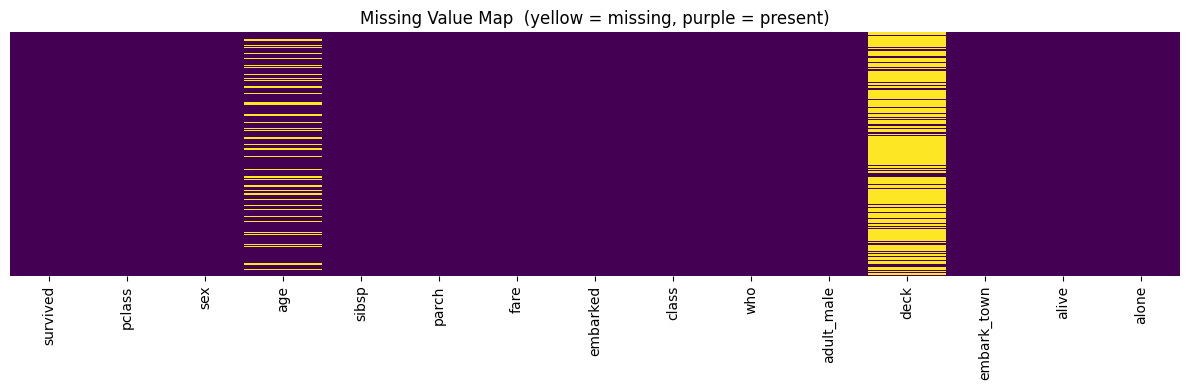

In [11]:
# Missing value heatmap — spot patterns in where data is absent
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Map  (yellow = missing, purple = present)')
plt.tight_layout()
plt.show()

## Key Takeaways

| Concept | Key Point |
|---|---|
| Numerical | Continuous (any value) or Discrete (countable) |
| Categorical | Nominal (no order) or Ordinal (has order) |
| Chart selection | Match chart type to data type — wrong chart = wrong insight |
| Data profiling | Check shape, missing values, distributions, relationships |
| Cardinality | Low cardinality numerical → likely ordinal/binary |